# SIT720 (Machine Learning) High Distinction Task: Reproduction and Extension of a Published Machine Learning Study

## Student Name: Ananya Gupta (S225274846)

## An Efficient Stacking-Based Ensemble Technique for Early Heart Attack Prediction

This notebook reproduces and critically evaluates the machine learning methodology presented in the selected research paper, *“An Efficient Stacking-Based Ensemble Technique for Early Heart Attack Prediction”* by Bhagat, Sharma and Agarwal.

The notebook is divided into two main parts:

### Part 1: Reproduction of the Published Study
The first part aims to reproduce the experimental methodology described in the paper as closely as possible. This includes:
- examining and preparing the heart disease dataset used by the authors;
- reproducing the preprocessing procedure described in the paper;
- implementing the individual machine learning classifiers;
- reproducing the proposed stacking ensemble;
- evaluating all models using Accuracy, Precision, Recall, F1 Score and AUC;
- comparing the reproduced results with the results reported in the paper; and
- critically analysing differences between the published and reproduced results.

Where implementation details are not fully specified in the paper, reasonable assumptions are documented and justified to maintain transparency and reproducibility.

### Part 2: Proposed Machine Learning Solution
The second part identifies limitations of the reproduced approach and develops a substantially different machine learning solution intended to address these limitations. The proposed method is evaluated using the same core performance metrics and compared with both the reproduced baseline and the published results. 

## GenAI Acknowledgement: 
I used AI as a support tool during this task for planning the structure of my work, discussing methodological choices, and helping me review whether I addressed the assessment requirements. I critically reviewed, verified and adapted the suggestions against my own implementation, experimental outputs, the selected research paper and supporting literature. The final analysis, code execution, interpretation and submitted work remain my responsibility. 

# Part 1: Understanding and Reproducing the Published Results


### 1.1 Research Problem and Motivation

In this project, I reproduce the study *An Efficient Stacking-Based Ensemble Technique for Early Heart Attack Prediction* by Bhagat, Sharma and Agarwal. The research focuses on using machine learning to predict heart disease from patient clinical information.

The motivation for the study is the serious impact of cardiovascular disease and the importance of identifying high-risk patients as early as possible. The authors explain that early detection and prevention can improve patient outcomes and allow healthcare providers to intervene before more serious health consequences occur. They also identify limitations in conventional cardiovascular risk assessment methods and discuss how the increasing availability of healthcare data creates opportunities for machine learning approaches to support heart disease prediction.

The main research objective of the paper is therefore to develop a highly accurate approach for predicting heart disease using clinical patient data and machine learning.

### 1.2 Existing Approaches and Research Context

The paper reviews a range of previous machine learning approaches for heart disease prediction. These include individual classification algorithms as well as hybrid and ensemble-based approaches. Previous studies discussed by the authors have applied methods such as Random Forest, Support Vector Machine, K-Nearest Neighbours, Decision Trees and Naive Bayes. The related work also includes approaches that combine machine learning with techniques such as feature selection, Principal Component Analysis and ensemble learning.

For example, the paper discusses a hybrid Random Forest and Linear Model approach that achieved 88.47% accuracy, as well as a feature-reduction approach combining chi-square and Principal Component Analysis that reported accuracies of 98.7%, 99.0% and 99.4% across different heart disease datasets. These previous results show that both individual classifiers and combined machine learning approaches have been investigated for improving cardiovascular disease prediction.

### 1.3 Research Gap and Proposed Contribution

From the research context presented in the paper, I understand the main problem being addressed as the need to improve the reliability and predictive performance of heart disease classification rather than depending on a single machine learning model. Different classifiers have different strengths and may produce different predictions, which provides motivation for combining their outputs through ensemble learning.

The authors address this by first constructing a more comprehensive dataset by combining four heart disease datasets. They then evaluate six individual classifiers: Logistic Regression, Decision Tree, Random Forest, Extreme Gradient Boosting (XGBoost), Naive Bayes and K-Nearest Neighbours.

The main proposed improvement is a stacking ensemble that combines the individual classifiers through a meta-classifier. Instead of relying on one classifier, stacking uses the predictions produced by multiple base models as information for a higher-level model. The paper reports that this approach improves predictive performance compared with the individual classifiers.

The main contributions identified by the authors are therefore the construction of the combined dataset, evaluation of six different classification models, and application of a stacking ensemble to improve prediction performance.

### 1. Experimental Setup

The required Python libraries are imported below. A fixed random state will be used where appropriate so that experiments involving randomisation can be reproduced consistently.

In [7]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Data preprocessing and model evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Reproducibility
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)

Libraries imported successfully.
Random state: 42


### 2. Dataset Acquisition

The selected paper uses the publicly available Heart Disease Dataset hosted on Kaggle. The dataset originates from four heart disease databases: Cleveland, Hungary, Switzerland and Long Beach V.

Although the original database contains a larger number of attributes, the published experiment uses 14 attributes, including the binary target variable. The paper reports a total of 1,025 patient records.

To reproduce the study as closely as possible, the dataset referenced by the authors is downloaded directly from its stated Kaggle source.

In [9]:
%pip install kagglehub -q

Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
import kagglehub
import pandas as pd

# Using the dataset included in this repository when available
local_file = os.path.join("data", "heart.csv")

if os.path.exists(local_file):
    csv_path = local_file
    print("Using repository dataset:")
    print(csv_path)
else:
# Fallback: downloading the dataset referenced in the paper
    dataset_path = kagglehub.dataset_download(
        "johnsmith88/heart-disease-dataset"
    )
    csv_path = os.path.join(dataset_path, "heart.csv")
    print("Repository dataset not found.")
    print("Downloaded original dataset from Kaggle:")
    print(csv_path)

# Load dataset
df = pd.read_csv(csv_path)

print("\nDataset shape:", df.shape)

Repository dataset not found.
Downloaded original dataset from Kaggle:
/Users/ananyagupta/.cache/kagglehub/datasets/johnsmith88/heart-disease-dataset/versions/2/heart.csv

Dataset shape: (1025, 14)


In [11]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
print(df["target"].value_counts())
print("\nColumns:")
print(df.columns.tolist())

Shape: (1025, 14)
Duplicate rows: 723

Target distribution:
target
1    526
0    499
Name: count, dtype: int64

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


### 2.1 Loading the Dataset

The downloaded heart disease dataset is loaded into a pandas DataFrame. The first stage of the reproduction is to verify that its dimensions and attributes correspond to the dataset described in the published study.

In [13]:
print("Dataset shape:", df.shape)

print("\nFirst five observations:")
display(df.head())

Dataset shape: (1025, 14)

First five observations:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 2.2 Verification of Dataset Structure

Before preprocessing or model training, the dataset structure is examined to verify its consistency with the description provided in the paper. This includes checking the number of observations and features, column names, data types, target classes, missing values and duplicate observations.

This verification is particularly important in a reproduction study because differences in the dataset or preprocessing procedure can lead to differences between reproduced and published results.

In [15]:
print("Number of observations:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nTarget classes:")
print(sorted(df["target"].unique()))

print("\nTarget class distribution:")
print(df["target"].value_counts().sort_index())

print("\nTarget class percentages:")
print((df["target"].value_counts(normalize=True).sort_index() * 100).round(2))

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Number of observations: 1025
Number of columns: 14

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Target classes:
[0, 1]

Target class distribution:
target
0    499
1    526
Name: count, dtype: int64

Target class percentages:
target
0    48.68
1    51.32
Name: proportion, dtype: float64

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

Number of duplicate rows: 723


### 2.3 Initial Dataset Observations

The downloaded dataset contains 1,025 observations and 14 columns, which is consistent with the dataset dimensions described in the selected paper. The 14 columns consist of 13 predictor variables and the binary `target` variable.

The target classes are relatively balanced, with 499 observations (48.68%) belonging to class 0 and 526 observations (51.32%) belonging to class 1. Therefore, there is no substantial class imbalance in the dataset used for this reproduction.

No missing values were identified in the downloaded dataset. Although the paper describes missing-value handling as part of its general preprocessing procedure, no imputation is required for this version of the dataset.

An important observation is that 723 of the 1,025 rows are duplicates. These duplicates are retained for the initial reproduction because the aim of Part 1 is to reproduce the published experiment using the dataset referenced by the authors rather than modify its composition. However, the high number of duplicate observations may have implications for model evaluation if identical records occur across the training and testing sets. This issue will therefore be investigated separately when critically evaluating the reproduced methodology.

### 2.4 Feature Characteristics

The predictor variables include both continuous clinical measurements and categorical variables represented using numerical codes. The range and number of unique values for each feature are examined before preprocessing so that scaling and feature treatment can be applied appropriately.

In [18]:
# Summary statistics for all variables
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [19]:
# Number of unique values in each column
unique_counts = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Minimum": df.min(),
    "Maximum": df.max()
})

display(unique_counts)

,Unique Values,Minimum,Maximum
age,41,29.0,77.0
sex,2,0.0,1.0
cp,4,0.0,3.0
trestbps,49,94.0,200.0
chol,152,126.0,564.0
fbs,2,0.0,1.0
restecg,3,0.0,2.0
thalach,91,71.0,202.0
exang,2,0.0,1.0
oldpeak,40,0.0,6.2


In [20]:
categorical_features = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

print("Unique values for categorical features:\n")

for feature in categorical_features:
    print(f"{feature}: {sorted(df[feature].unique())}")

Unique values for categorical features:

sex: [0, 1]
cp: [0, 1, 2, 3]
fbs: [0, 1]
restecg: [0, 1, 2]
exang: [0, 1]
slope: [0, 1, 2]
ca: [0, 1, 2, 3, 4]
thal: [0, 1, 2, 3]


### 2.5 Feature Analysis

The dataset contains a mixture of continuous clinical measurements and categorical variables represented using numerical codes. The continuous variables include `age`, `trestbps`, `chol`, `thalach` and `oldpeak`. These variables have noticeably different numerical ranges. For example, cholesterol ranges from 126 to 564, whereas `oldpeak` ranges from 0 to 6.2.

The remaining predictors (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca` and `thal`) contain a small number of discrete values and represent categorical or ordinal clinical characteristics using numerical codes.

This distinction is important when reproducing the preprocessing procedure because the paper describes both categorical encoding and feature normalisation. In the downloaded dataset, the categorical variables have already been represented numerically and therefore do not require conversion from text labels before modelling.

## 3. Data Preparation and Reproduction Protocol

The next stage prepares the dataset for reproducing the machine learning experiments reported in the paper. The target variable is separated from the 13 predictor variables before the data are divided into training and testing sets.

The paper describes data preprocessing, normalisation and division into training and testing subsets, but does not provide all implementation details required to recreate the exact partition, including the random seed used. Therefore, where an exact setting is unavailable, a documented reproduction assumption is used.

For the initial reproduction, all 1,025 observations are retained, including duplicate observations, because this corresponds to the dataset referenced and evaluated by the authors. The effect of duplicate observations on model evaluation will be investigated separately as part of the critical analysis.

In [23]:
# Separating predictor variables and target
X = df.drop(columns="target")
y = df["target"]

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Predictor matrix shape: (1025, 13)
Target vector shape: (1025,)


### 3.1 Inferring the Published Test-Set Size

The paper does not clearly specify the exact proportion used for the final training and testing partition. However, the reported accuracy values can provide evidence about the likely test-set size because classification accuracy is calculated as the number of correctly classified observations divided by the total number of test observations.

The following calculation compares several commonly used test-set proportions with the published accuracy values to determine whether the reported percentages are consistent with a particular test-set size.

In [25]:
# Accuracy values reported in Table 11 of the paper
published_accuracies = {
    "Logistic Regression": 0.8439,
    "Naive Bayes": 0.8439,
    "KNN": 0.8585,
    "Decision Tree": 0.9268,
    "Random Forest": 0.9268,
    "XGBoost": 0.9073,
    "Stacking": 0.9853
}

# Common train/test proportions for a dataset of 1,025 observations
candidate_test_sizes = {
    "10%": round(len(df) * 0.10),
    "20%": round(len(df) * 0.20),
    "30%": round(len(df) * 0.30)
}

for split, n_test in candidate_test_sizes.items():
    print(f"\n{split} test set ({n_test} observations)")
    
    for model, accuracy in published_accuracies.items():
        implied_correct = accuracy * n_test
        print(
            f"{model:20s}: "
            f"implied correct predictions = {implied_correct:.2f}"
        )


10% test set (102 observations)
Logistic Regression : implied correct predictions = 86.08
Naive Bayes         : implied correct predictions = 86.08
KNN                 : implied correct predictions = 87.57
Decision Tree       : implied correct predictions = 94.53
Random Forest       : implied correct predictions = 94.53
XGBoost             : implied correct predictions = 92.54
Stacking            : implied correct predictions = 100.50

20% test set (205 observations)
Logistic Regression : implied correct predictions = 173.00
Naive Bayes         : implied correct predictions = 173.00
KNN                 : implied correct predictions = 175.99
Decision Tree       : implied correct predictions = 189.99
Random Forest       : implied correct predictions = 189.99
XGBoost             : implied correct predictions = 186.00
Stacking            : implied correct predictions = 201.99

30% test set (308 observations)
Logistic Regression : implied correct predictions = 259.92
Naive Bayes         : 

### 3.2 Reproduction Assumption: Train/Test Split

The published accuracy values provide strong evidence that the authors evaluated the models using a test set containing 205 observations, corresponding to a 20% test split of the 1,025-record dataset.

For example, an accuracy of 84.39% corresponds to approximately 173 correctly classified observations out of 205, while 92.68% corresponds to approximately 190 correct predictions and 98.53% corresponds to approximately 202 correct predictions. The same relationship is observed across all seven reported models.

Therefore, an 80% training and 20% testing split is used for this reproduction. The paper does not report the random seed used to generate the partition, so a fixed random state of 42 is used as a reproducibility assumption. Stratification is also applied to preserve the approximately balanced target-class distribution in both subsets.

These settings should be regarded as reproduction assumptions where they are not explicitly specified by the authors.

In [27]:
# 80/20 train-test split inferred from the published accuracy values
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training observations: 820
Testing observations: 205

Training class distribution:
target
0    399
1    421
Name: count, dtype: int64

Testing class distribution:
target
0    100
1    105
Name: count, dtype: int64


### 3.3 Duplicate Overlap Between Training and Test Sets

The dataset contains a large number of duplicate observations. Because the initial reproduction retains the complete dataset, a random row-level train/test split may place identical observations in both subsets.

To evaluate this potential source of information leakage, the training and test sets are compared to determine how many test observations have an identical predictor record in the training data. This analysis does not alter the reproduction dataset; it is used to document a potential limitation of the experimental protocol.

In [29]:
# Comparing predictor records between training and test sets
train_unique = X_train.drop_duplicates()

test_matches_training = X_test.merge(
    train_unique,
    how="left",
    indicator=True
)["_merge"].eq("both")

overlap_count = test_matches_training.sum()
overlap_percentage = overlap_count / len(X_test) * 100

print("Test observations:", len(X_test))
print("Test observations with an identical predictor record in training:", overlap_count)
print(f"Percentage of test observations duplicated in training: {overlap_percentage:.2f}%")

Test observations: 205
Test observations with an identical predictor record in training: 202
Percentage of test observations duplicated in training: 98.54%


### 3.4 Interpretation of Duplicate Overlap

The overlap analysis identified a substantial limitation in the dataset used for the reproduction. Of the 205 observations in the test set, 202 (98.54%) have an identical predictor record in the training set. Therefore, under the row-level 80/20 split, almost the entire test set contains feature combinations that are already represented in the training data.

This does not automatically prove that the published results were affected by the same degree of overlap, because the exact random seed and train/test indices used by the authors are not reported. However, the large number of duplicate records in the complete dataset creates a substantial risk of train-test contamination when conventional random row-level splitting is used.

This issue is particularly important when interpreting very high test-set performance. A model evaluated on duplicate observations may achieve an optimistic estimate of its ability to generalise to genuinely unseen patient records. For the initial reproduction, the duplicate observations are retained so that the dataset remains consistent with the 1,025 observations used in the published study. The effect of duplicate observations will be investigated separately when critically evaluating the reproduced methodology.

## 4. Data Preprocessing

Before training the machine learning models, I prepared the predictor variables while keeping the same 13 features used in the published study.

The dataset contains a mixture of continuous clinical measurements and categorical variables represented using numerical codes. I standardised the continuous features `age`, `trestbps`, `chol`, `thalach` and `oldpeak`. I kept the categorical and discrete variables in their existing numerical representation.

I fitted the `StandardScaler` only on the training data and then applied the learned transformation to the test data. This prevents information from the test set from influencing the preprocessing stage and therefore avoids preprocessing-related data leakage.

After scaling, the continuous training features had means approximately equal to 0 and standard deviations equal to 1. The training and testing datasets remained unchanged in size, containing 820 and 205 observations respectively.

Where the paper does not clearly specify an implementation detail, I document the assumption I make so that the reproduction process remains transparent and reproducible.

In [32]:
# Creating copies so the original train/test data remain unchanged
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Continuous clinical variables to standardise
continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Fitting the scaler using training data only
scaler = StandardScaler()

X_train_processed[continuous_features] = scaler.fit_transform(
    X_train[continuous_features]
)

# Applying the same transformation to the test data
X_test_processed[continuous_features] = scaler.transform(
    X_test[continuous_features]
)

print("Continuous features standardised:")
print(continuous_features)

print("\nTraining data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

print("\nMean of scaled continuous training features:")
print(X_train_processed[continuous_features].mean().round(4))

print("\nStandard deviation of scaled continuous training features:")
print(X_train_processed[continuous_features].std(ddof=0).round(4))

Continuous features standardised:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Training data shape: (820, 13)
Testing data shape: (205, 13)

Mean of scaled continuous training features:
age        -0.0
trestbps    0.0
chol       -0.0
thalach     0.0
oldpeak     0.0
dtype: float64

Standard deviation of scaled continuous training features:
age         1.0
trestbps    1.0
chol        1.0
thalach     1.0
oldpeak     1.0
dtype: float64


## 5. Reproduction of Individual Machine Learning Classifiers

I next reproduced the individual machine learning classifiers evaluated in the published study before implementing the proposed stacking ensemble.

The paper evaluates six individual classifiers: Logistic Regression, Naive Bayes, K-Nearest Neighbours (KNN), Decision Tree, Random Forest and Extreme Gradient Boosting (XGBoost). I used the same training and test partition created earlier so that the models could be compared under a consistent experimental setup.

The paper does not provide complete hyperparameter settings for every classifier. Therefore, where an exact setting was not available, I used standard implementations and documented these choices as reproduction assumptions rather than treating them as settings explicitly reported by the authors.

For models that are sensitive to feature scale, I used the processed predictor data created in the previous section. Tree-based models were also evaluated using the same predictor representation to maintain a consistent feature set across the reproduction.

I evaluated every classifier using Accuracy, Precision, Recall, F1 Score and Area Under the ROC Curve (AUC), as required for the reproduction study.

### 5.1 Install/import XGBoost

In [35]:
%pip install xgboost -q

Note: you may need to restart the kernel to use updated packages.


In [36]:
from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


### 5.2 Model Configuration

I created one implementation of each individual classifier evaluated in the paper. Because complete classifier hyperparameters are not reported for all models, I used standard scikit-learn/XGBoost implementations where necessary.

I fixed the random state for models involving randomisation so that my results can be reproduced consistently. For Logistic Regression, I increased the maximum number of iterations to allow the optimisation procedure sufficient opportunity to converge.

These settings form my reproduction assumptions and will be considered when I later compare my results with those reported by the authors.

In [38]:
# Individual classifiers evaluated in the published study
individual_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}

print("Individual classifiers configured:\n")

for model_name, model in individual_models.items():
    print(f"- {model_name}: {model}")

Individual classifiers configured:

- Logistic Regression: LogisticRegression(max_iter=1000, random_state=42)
- Naive Bayes: GaussianNB()
- KNN: KNeighborsClassifier()
- Decision Tree: DecisionTreeClassifier(random_state=42)
- Random Forest: RandomForestClassifier(random_state=42)
- XGBoost: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_e

### 5.3 Training and Evaluation

I trained each individual classifier using the same training observations and evaluated it on the same held-out test set. This allowed me to compare the different machine learning methods under the same reproduced experimental conditions.

For each model, I calculated Accuracy, Precision, Recall, F1 Score and AUC. For AUC, I used the predicted probability of the positive class rather than the final binary class prediction.

In [40]:
# Storing results and fitted models
individual_results = []
fitted_individual_models = {}

for model_name, model in individual_models.items():

    print(f"Training {model_name}...")

    # Training model
    model.fit(X_train_processed, y_train)

    # Predictions
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    individual_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc
    })

    fitted_individual_models[model_name] = model

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")
    print("-" * 45)

Training Logistic Regression...
Accuracy : 0.8146
Precision: 0.7638
Recall   : 0.9238
F1 Score : 0.8362
AUC      : 0.9297
---------------------------------------------
Training Naive Bayes...
Accuracy : 0.8293
Precision: 0.8070
Recall   : 0.8762
F1 Score : 0.8402
AUC      : 0.9043
---------------------------------------------
Training KNN...
Accuracy : 0.8537
Precision: 0.8571
Recall   : 0.8571
F1 Score : 0.8571
AUC      : 0.9540
---------------------------------------------
Training Decision Tree...
Accuracy : 0.9854
Precision: 1.0000
Recall   : 0.9714
F1 Score : 0.9855
AUC      : 0.9857
---------------------------------------------
Training Random Forest...
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
AUC      : 1.0000
---------------------------------------------
Training XGBoost...
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
AUC      : 1.0000
---------------------------------------------


In [41]:
# Creating a summary table of reproduced results
individual_results_df = pd.DataFrame(individual_results)

individual_results_df = individual_results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(individual_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
1,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
2,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
3,KNN,0.8537,0.8571,0.8571,0.8571,0.9540
4,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
5,Logistic Regression,0.8146,0.7638,0.9238,0.8362,0.9297


## 6. Reproduction of the Proposed Stacking Ensemble

The main contribution of the selected paper is its stacking-based ensemble for heart attack prediction. After reproducing the individual classifiers, I next reproduce the proposed stacking approach so that I can compare its performance with both the individual models and the results reported by the authors.

In stacking, predictions from multiple base classifiers are combined by a higher-level model. This allows the ensemble to use information learned by different classifiers rather than relying on the predictions of a single model.

I use the six individual classifiers evaluated in the paper as the base models: Logistic Regression, Decision Tree, Random Forest, XGBoost, Naive Bayes and K-Nearest Neighbours. The paper describes the proposed approach as a 5-fold stacking ensemble, so I use five-fold stacking in my reproduction.

Although the paper explains the role of a meta-classifier in stacking, it does not clearly specify which classifier was used as the final meta-classifier in the reported experiment. I therefore use Logistic Regression as the meta-classifier as a reasonable reproduction assumption. I document this choice explicitly because differences in unspecified implementation details may contribute to differences between my reproduced results and the published results.

### 6.1 Stacking Ensemble Configuration

I constructed the stacking ensemble using the same six classifiers that I evaluated individually. Each classifier acts as a base learner, while Logistic Regression is used as the final meta-classifier based on the reproduction assumption described above.

I use five-fold cross-validation within the stacking procedure to generate predictions from the base learners for training the meta-classifier. This follows the 5-fold stacking structure described in the paper and also prevents the meta-classifier from being trained directly on predictions produced from the same observations used to fit each base learner.

I keep the model settings and random state consistent with my individual-model reproduction wherever applicable so that the stacking result can be compared fairly with the earlier results.

In [44]:
# Base classifiers used in the stacking ensemble
stacking_estimators = [
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )),
    
    ("dt", DecisionTreeClassifier(
        random_state=RANDOM_STATE
    )),
    
    ("rf", RandomForestClassifier(
        random_state=RANDOM_STATE
    )),
    
    ("xgb", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )),
    
    ("nb", GaussianNB()),
    
    ("knn", KNeighborsClassifier())
]

# Logistic Regression is used as the meta-classifier
meta_classifier = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Reproducing the paper's 5-fold stacking structure
stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=meta_classifier,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

print("Stacking ensemble configured successfully.")
print("\nBase classifiers:")
for name, model in stacking_estimators:
    print(f"- {name}: {model.__class__.__name__}")

print("\nMeta-classifier:")
print(meta_classifier)

print("\nNumber of stacking folds:", stacking_model.cv)

Stacking ensemble configured successfully.

Base classifiers:
- lr: LogisticRegression
- dt: DecisionTreeClassifier
- rf: RandomForestClassifier
- xgb: XGBClassifier
- nb: GaussianNB
- knn: KNeighborsClassifier

Meta-classifier:
LogisticRegression(max_iter=1000, random_state=42)

Number of stacking folds: 5


### 6.2 Training and Evaluation of the Stacking Ensemble

I train the stacking ensemble using the same processed training data used for the individual classifiers and evaluate it on the same held-out test set. This ensures that differences in performance are due to the modelling approach rather than differences in the evaluation data.

I evaluate the ensemble using Accuracy, Precision, Recall, F1 Score and AUC, which are the core evaluation metrics required for the reproduction. For AUC, I use the predicted probability of the positive class.

In [46]:
# Training the stacking ensemble
stacking_model.fit(X_train_processed, y_train)

# Predictions on the held-out test set
stacking_predictions = stacking_model.predict(X_test_processed)
stacking_probabilities = stacking_model.predict_proba(X_test_processed)[:, 1]

# Evaluation metrics
stacking_accuracy = accuracy_score(y_test, stacking_predictions)
stacking_precision = precision_score(y_test, stacking_predictions)
stacking_recall = recall_score(y_test, stacking_predictions)
stacking_f1 = f1_score(y_test, stacking_predictions)
stacking_auc = roc_auc_score(y_test, stacking_probabilities)

print("Reproduced Stacking Ensemble Results")
print("-------------------------------------")
print(f"Accuracy : {stacking_accuracy:.4f}")
print(f"Precision: {stacking_precision:.4f}")
print(f"Recall   : {stacking_recall:.4f}")
print(f"F1 Score : {stacking_f1:.4f}")
print(f"AUC      : {stacking_auc:.4f}")

Reproduced Stacking Ensemble Results
-------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
AUC      : 1.0000


### 6.3 Comparison with the Published Stacking Result

I next compare the performance of my reproduced stacking ensemble with the result reported in the original paper. This comparison is important because exact reproduction may not be possible where implementation details, such as the final meta-classifier and some classifier parameters, are not fully specified.

I also consider the duplicate overlap identified earlier when interpreting the reproduced performance, since almost all observations in my held-out test set have an identical predictor record in the training data.

In [48]:
# Comparing reproduced stacking results with the published results

stacking_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],
    "Published Result": [
        0.9853,
        1.0000,
        0.9727,
        0.9861,
        0.9880
    ],
    "Reproduced Result": [
        stacking_accuracy,
        stacking_precision,
        stacking_recall,
        stacking_f1,
        stacking_auc
    ]
})

stacking_comparison["Difference"] = (
    stacking_comparison["Reproduced Result"]
    - stacking_comparison["Published Result"]
)

display(stacking_comparison.round(4))

,Metric,Published Result,Reproduced Result,Difference
0,Accuracy,0.9853,1.0,0.0147
1,Precision,1.0000,1.0,0.0000
2,Recall,0.9727,1.0,0.0273
3,F1 Score,0.9861,1.0,0.0139
4,AUC,0.9880,1.0,0.0120


### 6.4 Investigating Differences from the Published Results

My reproduced stacking ensemble achieved perfect performance on the held-out test set, which is higher than the performance reported in the paper. Random Forest and XGBoost also achieved perfect accuracy in my reproduction. Therefore, before interpreting the difference as an improvement, I investigate characteristics of the dataset and experimental split that may have contributed to these results.

In particular, I examine whether duplicate observations are present in the dataset and whether identical feature records occur across the training and testing partitions. This is important because repeated observations across the two partitions could make the test set less independent from the training data and lead to unusually high performance.

In [50]:
# Investigating duplicate observations in the dataset

print("Total observations:", len(df))
print("Fully duplicated rows:", df.duplicated().sum())

# Converting the processed training and testing feature sets to DataFrames
X_train_check = pd.DataFrame(X_train).reset_index(drop=True)
X_test_check = pd.DataFrame(X_test).reset_index(drop=True)

# Checking whether test feature rows also occur in the training data
train_rows = set(map(tuple, X_train_check.to_numpy()))
test_rows = list(map(tuple, X_test_check.to_numpy()))

test_rows_seen_in_training = sum(
    row in train_rows for row in test_rows
)

print("Training observations:", len(X_train_check))
print("Testing observations:", len(X_test_check))
print(
    "Test observations with an identical feature row in training:",
    test_rows_seen_in_training
)
print(
    "Percentage of test observations also represented in training:",
    f"{100 * test_rows_seen_in_training / len(X_test_check):.2f}%"
)

Total observations: 1025
Fully duplicated rows: 723
Training observations: 820
Testing observations: 205
Test observations with an identical feature row in training: 202
Percentage of test observations also represented in training: 98.54%


### 6.5 Critical Analysis of the Reproduced Stacking Result

My reproduced stacking ensemble achieved an accuracy, precision, recall, F1 Score and AUC of 1.0000, compared with the published values of 0.9853, 1.0000, 0.9727, 0.9861 and 0.9880 respectively. Although my reproduced values are numerically higher, I do not interpret this as evidence that my implementation provides better generalisation than the model reported in the paper.

My duplicate analysis provides an important explanation for this result. Of the 1,025 observations in the dataset, 723 are duplicated rows. More importantly, 202 of the 205 observations in my held-out test set have an identical feature record in the training set. This means that 98.54% of the test observations are already represented by the same predictor values during training.

This substantial overlap reduces the independence of the test set and can make the classification problem considerably easier, particularly for flexible tree-based models that can learn or effectively memorise repeated patterns. This is consistent with my experimental results: Random Forest and XGBoost both achieved 100% on the test set, and the stacking ensemble that includes these classifiers also achieved perfect performance.

Therefore, the difference between my reproduced stacking accuracy of 100% and the published accuracy of 98.53% is likely influenced by the random train/test partition and the large number of duplicate observations in the dataset. Other factors may also contribute because the paper does not report every implementation detail, including the exact random split, all classifier hyperparameters, or the final stacking meta-classifier. My reproduction therefore demonstrates that the reported performance is highly sensitive to the experimental protocol and, in particular, to how duplicate observations are distributed between the training and test sets.

## 7. Comparison of Published and Reproduced Results

After reproducing the six individual classifiers and the proposed stacking ensemble, I compare my experimental results with the results reported in the selected paper. This allows me to determine how closely the published findings can be reproduced and to identify where the largest differences occur.

I compare the models using Accuracy, Precision, Recall, F1 Score and AUC. I also consider the duplicate-overlap analysis from the previous section when interpreting unusually high reproduced performance.

In [53]:
# Published classification results reported by Bhagat et al. [1]
published_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Stacking"
    ],
    "Published Accuracy": [
        0.8439, 0.8439, 0.8585, 0.9268, 0.9268, 0.9073, 0.9853
    ],
    "Published Precision": [
        0.8196, 0.8250, 0.8648, 0.9702, 0.9130, 0.9174, 1.0000
    ],
    "Published Recall": [
        0.9090, 0.9000, 0.8727, 0.8909, 0.9545, 0.9090, 0.9727
    ],
    "Published F1 Score": [
        0.8620, 0.8608, 0.8687, 0.9289, 0.9333, 0.9132, 0.9861
    ],
    "Published AUC": [
        0.9204, 0.9185, 0.9304, 0.9702, 0.9734, 0.9830, 0.9880
    ]
})

display(published_results)

,Model,Published Accuracy,Published Precision,Published Recall,Published F1 Score,Published AUC
0,Logistic Regression,0.8439,0.8196,0.9090,0.8620,0.9204
1,Naive Bayes,0.8439,0.8250,0.9000,0.8608,0.9185
2,KNN,0.8585,0.8648,0.8727,0.8687,0.9304
3,Decision Tree,0.9268,0.9702,0.8909,0.9289,0.9702
4,Random Forest,0.9268,0.9130,0.9545,0.9333,0.9734
5,XGBoost,0.9073,0.9174,0.9090,0.9132,0.9830
6,Stacking,0.9853,1.0000,0.9727,0.9861,0.9880


In [54]:
# Displaying all reproduced individual model results
display(individual_results_df.round(4))

print("\nReproduced Stacking Ensemble:")
print(f"Accuracy : {stacking_accuracy:.4f}")
print(f"Precision: {stacking_precision:.4f}")
print(f"Recall   : {stacking_recall:.4f}")
print(f"F1 Score : {stacking_f1:.4f}")
print(f"AUC      : {stacking_auc:.4f}")

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
1,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
2,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
3,KNN,0.8537,0.8571,0.8571,0.8571,0.9540
4,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
5,Logistic Regression,0.8146,0.7638,0.9238,0.8362,0.9297



Reproduced Stacking Ensemble:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
AUC      : 1.0000


In [55]:
# Reproduced results obtained from my implementation
individual_results_df = pd.DataFrame(individual_results)

reproduced_results = individual_results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
].copy()

# Adding the reproduced stacking ensemble
stacking_row = pd.DataFrame({
    "Model": ["Stacking"],
    "Accuracy": [stacking_accuracy],
    "Precision": [stacking_precision],
    "Recall": [stacking_recall],
    "F1 Score": [stacking_f1],
    "AUC": [stacking_auc]
})

reproduced_results = pd.concat(
    [reproduced_results, stacking_row],
    ignore_index=True
)

# Combining published and reproduced results
comparison_results = published_results.merge(
    reproduced_results,
    on="Model"
)

comparison_results = comparison_results.rename(columns={
    "Accuracy": "Reproduced Accuracy",
    "Precision": "Reproduced Precision",
    "Recall": "Reproduced Recall",
    "F1 Score": "Reproduced F1 Score",
    "AUC": "Reproduced AUC"
})

display(comparison_results.round(4))

,Model,Published Accuracy,Published Precision,Published Recall,Published F1 Score,Published AUC,Reproduced Accuracy,Reproduced Precision,Reproduced Recall,Reproduced F1 Score,Reproduced AUC
0,Logistic Regression,0.8439,0.8196,0.9090,0.8620,0.9204,0.8146,0.7638,0.9238,0.8362,0.9297
1,Naive Bayes,0.8439,0.8250,0.9000,0.8608,0.9185,0.8293,0.8070,0.8762,0.8402,0.9043
2,KNN,0.8585,0.8648,0.8727,0.8687,0.9304,0.8537,0.8571,0.8571,0.8571,0.9540
3,Decision Tree,0.9268,0.9702,0.8909,0.9289,0.9702,0.9854,1.0000,0.9714,0.9855,0.9857
4,Random Forest,0.9268,0.9130,0.9545,0.9333,0.9734,1.0000,1.0000,1.0000,1.0000,1.0000
5,XGBoost,0.9073,0.9174,0.9090,0.9132,0.9830,1.0000,1.0000,1.0000,1.0000,1.0000
6,Stacking,0.9853,1.0000,0.9727,0.9861,0.9880,1.0000,1.0000,1.0000,1.0000,1.0000


### 7.1 Quantitative Comparison of Published and Reproduced Results

I next calculate the difference between my reproduced results and the results reported in the paper for each evaluation metric. This allows me to identify which classifiers were reproduced closely and which showed larger differences.

I calculate each difference as the reproduced result minus the published result. A positive value therefore indicates that my reproduced model achieved a higher value, while a negative value indicates that it achieved a lower value.

In [57]:
# Calculating differences between reproduced and published results
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]

difference_results = comparison_results[["Model"]].copy()

for metric in metrics:
    difference_results[f"{metric} Difference"] = (
        comparison_results[f"Reproduced {metric}"]
        - comparison_results[f"Published {metric}"]
    )

display(difference_results.round(4))

,Model,Accuracy Difference,Precision Difference,Recall Difference,F1 Score Difference,AUC Difference
0,Logistic Regression,-0.0293,-0.0558,0.0148,-0.0258,0.0093
1,Naive Bayes,-0.0146,-0.0180,-0.0238,-0.0206,-0.0142
2,KNN,-0.0048,-0.0077,-0.0156,-0.0116,0.0236
3,Decision Tree,0.0586,0.0298,0.0805,0.0566,0.0155
4,Random Forest,0.0732,0.0870,0.0455,0.0667,0.0266
5,XGBoost,0.0927,0.0826,0.0910,0.0868,0.0170
6,Stacking,0.0147,0.0000,0.0273,0.0139,0.0120


### 7.2 Analysis of Reproduction Differences

My reproduced results show that the performance of some classifiers is relatively close to the results reported in the paper, while other models show much larger differences.

KNN produced the closest reproduced accuracy, with an accuracy of 85.37% compared with the published value of 85.85%, a difference of only -0.48 percentage points. Naive Bayes and Logistic Regression also produced reasonably similar results, although their reproduced accuracies were lower by 1.46 and 2.93 percentage points respectively.

Larger differences were observed for the tree-based models. My Decision Tree achieved 98.54% accuracy compared with the published 92.68%, while Random Forest achieved 100% compared with 92.68%. The largest accuracy difference occurred for XGBoost, which achieved 100% in my reproduction compared with 90.73% in the paper. The reproduced stacking ensemble also achieved 100% across all five evaluation metrics, compared with the published accuracy of 98.53%, F1 Score of 98.61% and AUC of 98.80%.

An important finding from my earlier analysis is that the dataset contains a very large number of duplicate observations. Of the 1,025 rows, 723 are fully duplicated rows, and 202 of the 205 observations in my test set have an identical feature record in the training set. This means that 98.54% of the test set is represented by identical predictor records in the training data. Therefore, the perfect or near-perfect results obtained by some of my reproduced models should not automatically be interpreted as evidence of better generalisation. Instead, the substantial train-test overlap provides a likely explanation for why models such as Random Forest, XGBoost and the stacking ensemble achieved unusually high test performance.

The remaining differences may also be influenced by implementation details that are not fully specified in the paper, including the exact random train-test partition, complete classifier hyperparameters and the meta-classifier used in the stacking ensemble. I therefore treat my reproduction as an implementation based on the methodology and information available in the paper rather than an exact replication of every undocumented experimental setting.

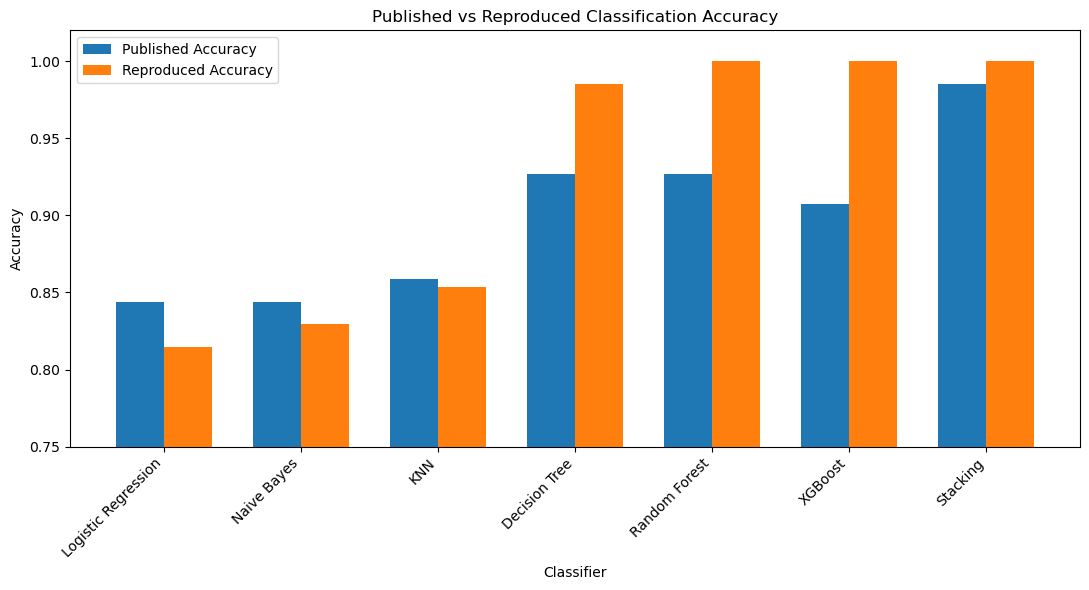

In [59]:
# Comparing published and reproduced accuracy for each model
import matplotlib.pyplot as plt
import numpy as np

models = comparison_results["Model"]
published_accuracy = comparison_results["Published Accuracy"]
reproduced_accuracy = comparison_results["Reproduced Accuracy"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width/2,
    published_accuracy,
    width,
    label="Published Accuracy"
)

plt.bar(
    x + width/2,
    reproduced_accuracy,
    width,
    label="Reproduced Accuracy"
)

plt.xticks(x, models, rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.xlabel("Classifier")
plt.title("Published vs Reproduced Classification Accuracy")
plt.ylim(0.75, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Part 1 Reproduction Summary

In Part 1, I reproduced the machine learning approach presented in the selected paper using the same 13 predictor features and the six individual classifiers: Logistic Regression, Naive Bayes, K-Nearest Neighbours, Decision Tree, Random Forest and XGBoost. I also reproduced the proposed stacking ensemble using the six classifiers as base models and five-fold stacking.

My reproduced results followed the published results reasonably closely for some models, particularly KNN, but larger differences were observed for the tree-based models. Logistic Regression, Naive Bayes and KNN achieved reproduced accuracies of 81.46%, 82.93% and 85.37%, respectively. Decision Tree achieved 98.54%, while Random Forest and XGBoost both achieved 100% accuracy. The reproduced stacking ensemble also achieved 100% across Accuracy, Precision, Recall, F1 Score and AUC.

These perfect results initially appeared stronger than the published results. However, my investigation of the dataset identified 723 fully duplicated rows among the 1,025 observations. I also found that 202 of the 205 test observations, or 98.54%, had an identical feature row represented in the training data. This provides an important explanation for the unusually high reproduced performance of models such as Random Forest, XGBoost and stacking, because the random train-test split does not provide a genuinely independent evaluation when duplicate patient records are distributed across both sets.

Therefore, I do not interpret the 100% reproduced accuracy as evidence that these models necessarily generalise perfectly to unseen patients. Instead, the reproduction highlights an important limitation of the experimental protocol and dataset structure. I use this finding as the main motivation for the improved machine learning solution developed in Part 2.

# Part 2 – Proposed Machine Learning Solution

## 9. Motivation and Proposed Methodology

### 9.1 Limitation Identified from the Reproduction

During the reproduction in Part 1, I identified an important limitation in the experimental dataset and evaluation procedure. The dataset contains 1,025 observations, but 723 rows are fully duplicated. When I reproduced the random 80/20 train-test split, I found that 202 of the 205 test observations had an identical feature record present in the training set. This means that 98.54% of the test observations were represented by identical predictor values in the training data.

This creates a problem when evaluating the generalisation performance of the machine learning models. If duplicate observations are distributed between the training and test sets, a model can be evaluated on observations that are identical to records it has already encountered during training. This may produce an overly optimistic estimate of performance on genuinely unseen observations.

This issue was particularly visible in my reproduction, where Random Forest, XGBoost and the stacking ensemble achieved 100% test accuracy. Although these results are numerically higher than those reported in the original paper, the substantial train-test overlap means that I cannot conclude that these models provide perfect generalisation.

### 9.2 Proposed Solution

To address this limitation, I propose a leakage-resistant machine learning pipeline that evaluates the models using unique observations rather than allowing duplicated observations to occur across the training and test sets.

The first major change is to remove exact duplicate observations before creating the train-test split. This ensures that identical records cannot occur in both sets and provides a more realistic evaluation on unseen observations.

I will then create a new stratified training and test split using the deduplicated dataset. Stratification will be used to maintain a similar distribution of the target classes between the training and test sets.

Preprocessing will be performed using the training data only. Continuous variables will be standardised without using information from the test set. Model selection and hyperparameter optimisation will also be performed only on the training data using cross-validation. The final test set will remain untouched until the selected model has been finalised.

This approach differs from the reproduced experiment because the main objective is not simply to obtain a higher test accuracy. Instead, I aim to develop a more reliable evaluation pipeline and then optimise model performance under this stricter experimental setting.

### 9.3 Experimental Design

The proposed experiment will consist of the following stages:

1. Remove exact duplicate observations from the original dataset.
2. Separate the predictor variables and target variable.
3. Create a stratified training and held-out test set.
4. Apply preprocessing using parameters learned only from the training data.
5. Establish baseline performance under the leakage-resistant protocol.
6. Perform cross-validated model and hyperparameter optimisation using the training set only.
7. Evaluate the final proposed model once on the untouched test set.
8. Measure performance using Accuracy, Precision, Recall, F1 Score and AUC.
9. Compare the proposed method with the reproduced results from Part 1 and the results reported in the original paper.
10. Analyse whether the proposed method provides more reliable evidence of generalisation despite using a more difficult evaluation protocol.

In [62]:
# Creating a deduplicated version of the dataset for Part 2
df_unique = df.drop_duplicates().reset_index(drop=True)

print("Original dataset shape:", df.shape)
print("Deduplicated dataset shape:", df_unique.shape)
print("Rows removed:", len(df) - len(df_unique))

print("\nTarget distribution after removing duplicates:")
print(df_unique["target"].value_counts())

print("\nTarget proportions:")
print(df_unique["target"].value_counts(normalize=True).round(4))

Original dataset shape: (1025, 14)
Deduplicated dataset shape: (302, 14)
Rows removed: 723

Target distribution after removing duplicates:
target
1    164
0    138
Name: count, dtype: int64

Target proportions:
target
1    0.543
0    0.457
Name: proportion, dtype: float64


### 9.4 Deduplicated Dataset and Held-outTrain-Test Split

After removing exact duplicate observations, the dataset was reduced from 1,025 to 302 unique observations, meaning that 723 duplicate rows were removed. The remaining dataset contained 164 positive cases (54.3%) and 138 negative cases (45.7%), so the target remained reasonably balanced.

I then created a new stratified 80/20 train-test split using only the unique observations. I retained the same test proportion used in my Part 1 reproduction to make the experimental settings more comparable. However, unlike the original reproduction, exact duplicate observations can no longer appear across the training and test sets.

I use the training set for model development and reserve the test set for final evaluation. The test set is not used for model selection or hyperparameter optimisation.

In [64]:
# Separating predictors and target from the deduplicated dataset
X_unique = df_unique.drop(columns=["target"])
y_unique = df_unique["target"]

# Creating a stratified 80/20 train-test split
X_train_p2, X_test_p2, y_train_p2, y_test_p2 = train_test_split(
    X_unique,
    y_unique,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_unique
)

print("Training set shape:", X_train_p2.shape)
print("Test set shape:", X_test_p2.shape)

print("\nTraining target distribution:")
print(y_train_p2.value_counts())
print(y_train_p2.value_counts(normalize=True).round(4))

print("\nTest target distribution:")
print(y_test_p2.value_counts())
print(y_test_p2.value_counts(normalize=True).round(4))

Training set shape: (241, 13)
Test set shape: (61, 13)

Training target distribution:
target
1    131
0    110
Name: count, dtype: int64
target
1    0.5436
0    0.4564
Name: proportion, dtype: float64

Test target distribution:
target
1    33
0    28
Name: count, dtype: int64
target
1    0.541
0    0.459
Name: proportion, dtype: float64


In [65]:
# Verifying that no identical predictor rows occur across training and test sets
train_rows_p2 = set(map(tuple, X_train_p2.to_numpy()))
test_rows_p2 = list(map(tuple, X_test_p2.to_numpy()))

overlap_p2 = sum(row in train_rows_p2 for row in test_rows_p2)

print("Test observations:", len(X_test_p2))
print("Test observations with an identical feature row in training:", overlap_p2)
print(
    "Percentage of test observations overlapping with training:",
    f"{overlap_p2 / len(X_test_p2) * 100:.2f}%"
)

Test observations: 61
Test observations with an identical feature row in training: 0
Percentage of test observations overlapping with training: 0.00%


### 9.5 Verification of Train-Test Independence

The deduplicated dataset produced 241 training observations and 61 test observations. Stratification maintained a similar target distribution across both sets, with positive cases representing 54.36% of the training set and 54.10% of the test set.

I also explicitly checked whether any test observation had an identical predictor row in the training set. No overlapping observations were found, giving a train-test overlap of 0.00%. This is a substantial change from my Part 1 reproduction, where 98.54% of test observations had an identical feature record in the training data.

This confirms that the Part 2 test set provides a stricter evaluation on observations that are not exact copies of training records.

In [67]:
# Creating separate copies for Part 2 preprocessing
X_train_p2_scaled = X_train_p2.copy()
X_test_p2_scaled = X_test_p2.copy()

# Fitting a new scaler using ONLY the Part 2 training data
scaler_p2 = StandardScaler()

X_train_p2_scaled[continuous_features] = scaler_p2.fit_transform(
    X_train_p2[continuous_features]
)

X_test_p2_scaled[continuous_features] = scaler_p2.transform(
    X_test_p2[continuous_features]
)

print("Training set shape:", X_train_p2_scaled.shape)
print("Test set shape:", X_test_p2_scaled.shape)

print("\nScaled training continuous-feature means:")
print(
    X_train_p2_scaled[continuous_features]
    .mean()
    .round(4)
)

print("\nScaled training continuous-feature standard deviations:")
print(
    X_train_p2_scaled[continuous_features]
    .std(ddof=0)
    .round(4)
)

Training set shape: (241, 13)
Test set shape: (61, 13)

Scaled training continuous-feature means:
age        -0.0
trestbps   -0.0
chol        0.0
thalach     0.0
oldpeak    -0.0
dtype: float64

Scaled training continuous-feature standard deviations:
age         1.0
trestbps    1.0
chol        1.0
thalach     1.0
oldpeak     1.0
dtype: float64


### 9.6 Leakage-Free Baseline Models

Before developing and optimising my proposed model, I first establish a baseline using the same six classifiers evaluated in Part 1: Logistic Regression, Naive Bayes, K-Nearest Neighbours, Decision Tree, Random Forest and XGBoost.

To preserve the held-out Part 2 test set for final evaluation, I do not evaluate these baseline models on the 61 test observations at this stage. Instead, I evaluate the baseline classifiers using stratified five-fold cross-validation on the 241-observation training set.

To prevent preprocessing information from leaking between cross-validation folds, I place the StandardScaler inside a machine learning Pipeline. The scaler is therefore fitted only on the training portion of each fold and then applied to its corresponding validation portion. Only the five continuous features are standardised, while the categorical features are passed through unchanged.

I evaluate the models using Accuracy, Precision, Recall, F1 Score and AUC, consistent with the evaluation metrics used throughout the study. This provides a leakage-resistant baseline before hyperparameter optimisation while keeping the held-out test set completely separate from model development.

In [69]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Stratified 5-fold cross-validation using only the Part 2 training data
cv_p2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Preprocessing performed separately inside each cross-validation fold
preprocessor_p2 = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_features)
    ],
    remainder="passthrough"
)

# Metrics used for baseline evaluation
scoring_p2 = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1 Score": "f1",
    "AUC": "roc_auc"
}

# Same six classifiers used in Part 1
baseline_models_p2 = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}

baseline_results_p2 = []

for name, model in baseline_models_p2.items():

    # Pipeline ensures preprocessing is fitted only on each training fold
    pipeline = Pipeline([
        ("preprocessor", preprocessor_p2),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train_p2,       # Raw training data (not pre-scaled data)
        y_train_p2,
        cv=cv_p2,
        scoring=scoring_p2,
        n_jobs=-1
    )

    baseline_results_p2.append({
        "Model": name,
        "Mean Accuracy": scores["test_Accuracy"].mean(),
        "Mean Precision": scores["test_Precision"].mean(),
        "Mean Recall": scores["test_Recall"].mean(),
        "Mean F1 Score": scores["test_F1 Score"].mean(),
        "Mean AUC": scores["test_AUC"].mean(),
        "SD AUC": scores["test_AUC"].std()
    })

baseline_results_p2 = pd.DataFrame(baseline_results_p2)

baseline_results_p2 = baseline_results_p2.sort_values(
    by="Mean AUC",
    ascending=False
).reset_index(drop=True)

display(baseline_results_p2.round(4))

,Model,Mean Accuracy,Mean Precision,Mean Recall,Mean F1 Score,Mean AUC,SD AUC
0,Logistic Regression,0.8420,0.8199,0.9234,0.8661,0.9149,0.0354
1,Random Forest,0.8257,0.8238,0.8778,0.8466,0.9097,0.0442
2,Naive Bayes,0.8172,0.8244,0.8624,0.8378,0.8950,0.0469
3,XGBoost,0.7964,0.8195,0.8160,0.8117,0.8884,0.0357
4,KNN,0.8213,0.8026,0.9080,0.8481,0.8622,0.0262
5,Decision Tree,0.8007,0.8064,0.8393,0.8193,0.7969,0.0202


### 9.7 Analysis of the Leakage-Free Baseline

The leakage-resistant cross-validation results show that model performance is more moderate after the duplicate observations are removed. Logistic Regression achieved the highest mean AUC of 0.9149 and the highest mean accuracy of 0.8420. It also achieved a high mean recall of 0.9234 and mean F1 Score of 0.8661.

The remaining models produced mean AUC values of 0.9097 for Random Forest, 0.8950 for Naive Bayes, 0.8884 for XGBoost, 0.8622 for KNN and 0.7969 for Decision Tree. KNN achieved the highest mean recall of 0.9080 after Logistic Regression, while the individual models showed different strengths across the evaluation metrics.

Unlike the Part 1 reproduction, these baseline results are obtained using only the 241-observation Part 2 training set through stratified five-fold cross-validation. Preprocessing is performed separately within each fold using a Pipeline, meaning that the StandardScaler is fitted only on the training portion of each fold before being applied to its validation portion. The 61-observation held-out test set is not used during this baseline evaluation.

Overall, Logistic Regression and Random Forest provide the strongest AUC performance among the baseline models, with mean AUC values of 0.9149 and 0.9097 respectively. I therefore use these results as evidence when selecting candidate models for further optimisation, while keeping the held-out test set separate for the final evaluation.

## 10. Cross-Validated Model Optimisation

I next optimise the strongest candidate models identified during cross-validation. To make the experimental protocol more rigorous, I integrate preprocessing and model training within a scikit-learn Pipeline.

This is an improvement over preprocessing the complete training set before cross-validation. When preprocessing is contained within the Pipeline, the scaler is fitted separately using only the training portion of each cross-validation fold. The corresponding validation fold therefore does not contribute information to the preprocessing parameters.

I first optimise Logistic Regression because it achieved the highest mean cross-validated AUC during the candidate-model assessment. Hyperparameter selection is performed using only the 241 training observations with stratified five-fold cross-validation. The held-out test set remains unused.

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

# Passing categorical variables through unchanged and standardise
# only the continuous variables inside each CV fold
preprocessor_p2 = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_features)
    ],
    remainder="passthrough"
)

# Logistic Regression pipeline
lr_pipeline_p2 = Pipeline([
    ("preprocessing", preprocessor_p2),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

# Hyperparameter search space
lr_param_grid_p2 = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"]
}

# Grid search using training data only
lr_grid_p2 = GridSearchCV(
    estimator=lr_pipeline_p2,
    param_grid=lr_param_grid_p2,
    scoring="roc_auc",
    cv=cv_p2,
    n_jobs=-1,
    return_train_score=True
)

lr_grid_p2.fit(X_train_p2, y_train_p2)

print("Best parameters:")
print(lr_grid_p2.best_params_)

print("\nBest mean cross-validated AUC:")
print(round(lr_grid_p2.best_score_, 4))

Best parameters:
{'classifier__C': 1, 'classifier__class_weight': 'balanced'}

Best mean cross-validated AUC:
0.9156


### 10.1 Logistic Regression Optimisation

The hyperparameter search selected a regularisation parameter of C = 1 and balanced class weighting. The optimised Logistic Regression achieved a mean cross-validated AUC of 0.9156, compared with 0.9149 before optimisation. 

The improvement in AUC is very small, indicating that Logistic Regression was already performing close to its best under the tested parameter settings. I therefore retain the optimised model as a candidate but do not interpret hyperparameter tuning alone as a substantial improvement.

I next optimise Random Forest because it achieved the second-highest mean AUC of 0.9097 in the baseline comparison and provides a substantially different nonlinear modelling approach from Logistic Regression.

In [74]:
# Random Forest pipeline
rf_pipeline_p2 = Pipeline([
    ("preprocessing", preprocessor_p2),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE
    ))
])

# Random Forest hyperparameter search space
rf_param_grid_p2 = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 3, 5, 8],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_grid_p2 = GridSearchCV(
    estimator=rf_pipeline_p2,
    param_grid=rf_param_grid_p2,
    scoring="roc_auc",
    cv=cv_p2,
    n_jobs=-1,
    return_train_score=True
)

rf_grid_p2.fit(X_train_p2, y_train_p2)

print("Best parameters:")
print(rf_grid_p2.best_params_)

print("\nBest mean cross-validated AUC:")
print(round(rf_grid_p2.best_score_, 4))

Best parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Best mean cross-validated AUC:
0.919


### 10.2 Random Forest Optimisation

The Random Forest hyperparameter search selected 100 trees, no maximum tree depth, square-root feature selection, a minimum of two samples required to split an internal node, and a minimum of four samples per leaf.

The optimised Random Forest achieved a mean cross-validated AUC of 0.9190. This improves on the untuned Random Forest AUC of 0.9097 and also slightly exceeds the optimised Logistic Regression AUC of 0.9156. 

An important result from the optimisation is the selection of `min_samples_leaf = 4`. Rather than allowing the trees to create leaves containing individual training observations, the selected model requires at least four observations in each leaf. This introduces additional regularisation and may reduce the tendency of the model to fit very small patterns in the limited training dataset.

Based on the cross-validation results, both optimised Random Forest and Logistic Regression remain strong candidates. Their different modelling approaches also make them suitable candidates for an ensemble, since Logistic Regression models a linear decision boundary while Random Forest captures nonlinear relationships and interactions between features.

## 11. Proposed Leakage-Resistant Soft-Voting Ensemble

The original paper uses stacking, where predictions from several base classifiers are provided to a meta-classifier. For my proposed solution, I use a different ensemble strategy based on soft voting.

The proposed ensemble combines the optimised Logistic Regression and Random Forest models. These models were selected from the training-only cross-validation experiments because they achieved the strongest AUC performance while representing substantially different modelling approaches.

In soft voting, the predicted probabilities from the component models are combined and the final classification is based on the resulting probability. This avoids training an additional meta-classifier on the relatively small deduplicated dataset.

I evaluate the proposed ensemble using stratified five-fold cross-validation on the training data before applying it to the held-out test set.

In [77]:
from sklearn.ensemble import VotingClassifier

# Using the best models identified through training-only optimisation
best_lr_p2 = lr_grid_p2.best_estimator_
best_rf_p2 = rf_grid_p2.best_estimator_

# Soft-voting ensemble
voting_p2 = VotingClassifier(
    estimators=[
        ("logistic_regression", best_lr_p2),
        ("random_forest", best_rf_p2)
    ],
    voting="soft"
)

# Evaluating proposed ensemble using training data only
voting_cv_scores = cross_validate(
    voting_p2,
    X_train_p2,
    y_train_p2,
    cv=cv_p2,
    scoring=scoring_p2,
    n_jobs=-1
)

print("Proposed Soft-Voting Ensemble - 5-Fold CV")
print(
    "Mean Accuracy:",
    round(voting_cv_scores["test_Accuracy"].mean(), 4)
)
print(
    "Mean Precision:",
    round(voting_cv_scores["test_Precision"].mean(), 4)
)
print(
    "Mean Recall:",
    round(voting_cv_scores["test_Recall"].mean(), 4)
)
print(
    "Mean F1 Score:",
    round(voting_cv_scores["test_F1 Score"].mean(), 4)
)
print(
    "Mean AUC:",
    round(voting_cv_scores["test_AUC"].mean(), 4)
)
print(
    "SD AUC:",
    round(voting_cv_scores["test_AUC"].std(), 4)
)

Proposed Soft-Voting Ensemble - 5-Fold CV
Mean Accuracy: 0.8461
Mean Precision: 0.8387
Mean Recall: 0.908
Mean F1 Score: 0.868
Mean AUC: 0.9254
SD AUC: 0.0337


### 11.1 Cross-Validation Performance of the Proposed Ensemble

The proposed soft-voting ensemble achieved a mean cross-validated accuracy of 0.8461, precision of 0.8387, recall of 0.9080, F1 Score of 0.8680 and AUC of 0.9254. The standard deviation of AUC across the five folds was 0.0337.

The ensemble achieved a higher mean AUC than both optimised component models. Optimised Logistic Regression achieved an AUC of 0.9156, while optimised Random Forest achieved 0.9190. Combining the two models through soft voting increased the mean cross-validated AUC to 0.9254.

The ensemble also maintained a high recall of 0.9080. This is particularly relevant to the heart disease prediction problem because recall represents the proportion of positive cases correctly identified by the model.

These results provide training-only empirical support for selecting the soft-voting ensemble as my final proposed model. Importantly, the model architecture and hyperparameters were selected without evaluating performance on the held-out test set. I therefore now use the previously untouched 61-observation test set once to estimate the final generalisation performance of the proposed solution.

## 12. Final Evaluation on the Held-out Test Set

After completing model selection and optimisation using only the training data, I fit the proposed soft-voting ensemble using all 241 training observations. I then evaluate it once on the held-out test set containing 61 unique observations.

This test set was not used during model selection, hyperparameter optimisation or ensemble design. It also has 0% exact predictor overlap with the training set. Therefore, this evaluation provides a more rigorous estimate of performance on unseen observations than the duplicate-overlapping evaluation identified during Part 1.

In [80]:
# Fitting the final proposed ensemble using all Part 2 training observations
voting_p2.fit(X_train_p2, y_train_p2)

# Final predictions on the previously untouched test set
y_pred_final_p2 = voting_p2.predict(X_test_p2)
y_prob_final_p2 = voting_p2.predict_proba(X_test_p2)[:, 1]

# Final evaluation metrics
final_results_p2 = pd.DataFrame({
    "Model": ["Proposed Soft-Voting Ensemble"],
    "Accuracy": [
        accuracy_score(y_test_p2, y_pred_final_p2)
    ],
    "Precision": [
        precision_score(y_test_p2, y_pred_final_p2)
    ],
    "Recall": [
        recall_score(y_test_p2, y_pred_final_p2)
    ],
    "F1 Score": [
        f1_score(y_test_p2, y_pred_final_p2)
    ],
    "AUC": [
        roc_auc_score(y_test_p2, y_prob_final_p2)
    ]
})

display(final_results_p2.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Proposed Soft-Voting Ensemble,0.7869,0.8125,0.7879,0.8,0.8777


### 12.1 Final Test Performance

On the held-out test set, the proposed soft-voting ensemble achieved an accuracy of 78.69%, precision of 81.25%, recall of 78.79%, F1 Score of 80.00% and AUC of 87.77%.

These results are lower than both the mean cross-validation performance observed during model development and the very high scores obtained during my Part 1 reproduction. However, the Part 2 test set represents a substantially stricter evaluation. All exact duplicate observations were removed before splitting the data, and none of the 61 test observations had an identical predictor record in the training set.

The reduction in performance should therefore not be interpreted simply as evidence that the proposed model is worse than the Part 1 models. The evaluation conditions are fundamentally different. In Part 1, 98.54% of test observations had an identical predictor record in the training data, whereas Part 2 reduced this overlap to 0%.

The proposed model also achieved a mean cross-validated AUC of 92.54% during training-only model development, compared with a final held-out test AUC of 87.77%. This difference indicates some variation in performance across samples and highlights the uncertainty associated with evaluating models using a relatively small dataset.

Overall, the proposed approach prioritises a more independent and reproducible estimate of generalisation performance rather than maximising performance on a test set containing repeated observations.

### 12.2 Confusion Matrix

I use a confusion matrix to examine the individual classification outcomes of the proposed model on the held-out test set. This allows me to identify the numbers of true positives, true negatives, false positives and false negatives rather than relying only on aggregate performance metrics.

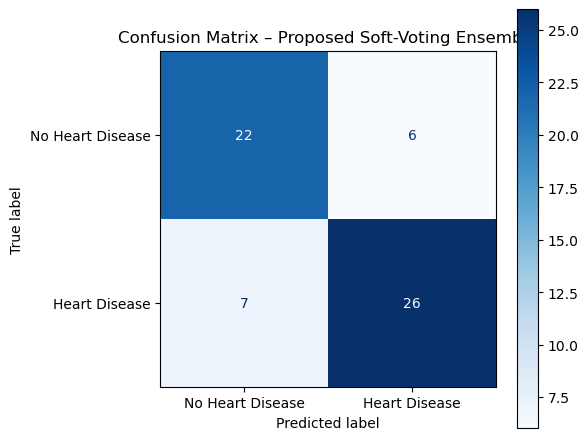

Confusion matrix:
[[22  6]
 [ 7 26]]


In [83]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_p2 = confusion_matrix(y_test_p2, y_pred_final_p2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_p2,
    display_labels=["No Heart Disease", "Heart Disease"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Confusion Matrix – Proposed Soft-Voting Ensemble")
plt.tight_layout()
plt.show()

print("Confusion matrix:")
print(cm_p2)

#### Confusion Matrix Analysis

The confusion matrix shows that the proposed model correctly classified 48 of the 61 heldout test observations. It correctly identified 22 patients without heart disease and 26 patients with heart disease.

The model produced six false positives, where patients without heart disease were predicted as having heart disease, and seven false negatives, where patients with heart disease were incorrectly predicted as not having heart disease.

The seven false negatives are particularly important in the context of heart disease prediction because these represent positive cases that the model failed to identify. This result is consistent with the final recall of 78.79%, as the model correctly identified 26 of the 33 positive cases in the test set.

Although the proposed model does not achieve the near-perfect classification observed during Part 1, these errors occur on a test set with no exact duplicate overlap with the training data. The confusion matrix therefore provides a more transparent view of the errors made when the model is evaluated on genuinely distinct observations.

### 12.3 ROC Curve

I also evaluate the proposed model using the Receiver Operating Characteristic (ROC) curve. Unlike accuracy, which evaluates predictions at a fixed classification threshold, the ROC curve shows the relationship between the true positive rate and false positive rate across different classification thresholds.

The Area Under the ROC Curve (AUC) summarises the model's ability to distinguish between the two target classes across these thresholds.

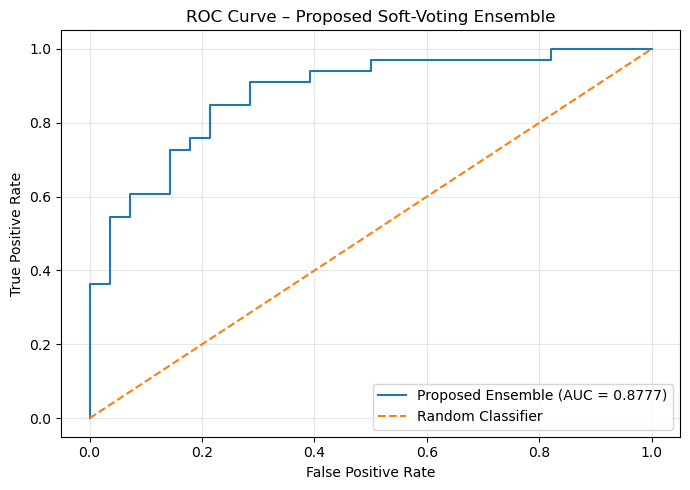

In [86]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculating ROC curve
fpr_p2, tpr_p2, thresholds_p2 = roc_curve(
    y_test_p2,
    y_prob_final_p2
)

auc_p2 = roc_auc_score(
    y_test_p2,
    y_prob_final_p2
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_p2,
    tpr_p2,
    label=f"Proposed Ensemble (AUC = {auc_p2:.4f})"
)

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Proposed Soft-Voting Ensemble")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### ROC Curve Analysis

The ROC curve shows that the proposed soft-voting ensemble performs substantially better than random classification across a range of classification thresholds. The model achieved an AUC of 0.8777 on the held-out test set.

An AUC of 0.8777 indicates that the model retains good ability to distinguish between the positive and negative classes even after exact duplicate overlap between the training and test sets has been removed. This is important because the evaluation is based on 61 distinct test observations that were not used during model development.

The test AUC is lower than the mean cross-validated AUC of 0.9254 obtained during model development. This difference suggests some variation in performance between validation folds and the held-out test sample, which is particularly relevant given the relatively small number of unique observations available after deduplication.

### 12.4 Cross-Validation Stability Analysis

To further examine the robustness of the proposed model, I compare its fold-level AUC performance with the two optimised component models using the same five cross-validation folds from the training data.

This analysis allows me to examine whether the improvement in mean AUC produced by the soft-voting ensemble is consistent across the validation folds or is mainly influenced by a particular fold. The held-out test set is not used in this analysis.

In [89]:
# Obtaining fold-level AUC scores for the optimised candidate models
lr_cv_final = cross_validate(
    best_lr_p2,
    X_train_p2,
    y_train_p2,
    cv=cv_p2,
    scoring="roc_auc",
    n_jobs=-1
)

rf_cv_final = cross_validate(
    best_rf_p2,
    X_train_p2,
    y_train_p2,
    cv=cv_p2,
    scoring="roc_auc",
    n_jobs=-1
)

# Using the previously calculated voting ensemble CV scores
fold_comparison_p2 = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Optimised Logistic Regression": lr_cv_final["test_score"],
    "Optimised Random Forest": rf_cv_final["test_score"],
    "Proposed Soft-Voting Ensemble": voting_cv_scores["test_AUC"]
})

display(fold_comparison_p2.round(4))

print("\nMean AUC:")
print(
    fold_comparison_p2
    .drop(columns="Fold")
    .mean()
    .round(4)
)

print("\nAUC Standard Deviation:")
print(
    fold_comparison_p2
    .drop(columns="Fold")
    .std(ddof=0)
    .round(4)
)

,Fold,Optimised Logistic Regression,Optimised Random Forest,Proposed Soft-Voting Ensemble
0,1,0.9697,0.9832,0.9764
1,2,0.8794,0.9353,0.9056
2,3,0.8934,0.8531,0.8864
3,4,0.9458,0.9580,0.9528
4,5,0.8899,0.8654,0.9056



Mean AUC:
Optimised Logistic Regression    0.9156
Optimised Random Forest          0.9190
Proposed Soft-Voting Ensemble    0.9254
dtype: float64

AUC Standard Deviation:
Optimised Logistic Regression    0.0355
Optimised Random Forest          0.0512
Proposed Soft-Voting Ensemble    0.0337
dtype: float64


#### Cross-Validation Stability Analysis

The fold-level results provide additional evidence about the behaviour of the proposed ensemble. The soft-voting ensemble achieved the highest overall mean AUC of 0.9254, compared with 0.9190 for the optimised Random Forest and 0.9156 for the optimised Logistic Regression.

However, the ensemble did not achieve the highest AUC in every individual fold. Random Forest achieved the highest AUC in folds 1, 2 and 4, Logistic Regression performed best in fold 3, and the proposed ensemble achieved the highest AUC in fold 5. Therefore, the improvement produced by soft voting is not uniform across every validation subset.

The proposed ensemble nevertheless produced the lowest AUC standard deviation of 0.0337, compared with 0.0355 for Logistic Regression and 0.0512 for Random Forest. This indicates that its AUC varied slightly less across the five validation folds, particularly compared with Random Forest.

Overall, the results support the ensemble as a reasonable final model because it achieved the highest mean cross-validated AUC while also showing relatively stable performance across folds. However, the improvement over the individual models is modest, and the fold-level results show that the ensemble does not consistently outperform both component models in every validation sample. I therefore treat the ensemble as an incremental modelling improvement within the larger methodological contribution of the leakage-resistant evaluation pipeline.

## 13. Comparison with Published and Reproduced Results

I next compare the final proposed solution with the stacking ensemble reported in the selected paper and the stacking ensemble reproduced in Part 1.

This comparison must be interpreted together with the experimental protocol. The published and Part 1 results are based on the original 1,025-row dataset, whereas my proposed method removes exact duplicate observations before model development and is evaluated using 302 unique observations. In my Part 1 split, 98.54% of test observations had an identical predictor record in the training data. In Part 2, this overlap was reduced to 0%.

Therefore, the performance values are not directly equivalent estimates obtained under identical evaluation conditions. I present them together to demonstrate how model performance changes when the identified duplicate-overlap limitation is addressed.

In [92]:
# Comparison of the published stacking model,
# Part 1 reproduced stacking model, and Part 2 proposed solution

final_comparison = pd.DataFrame({
    "Approach": [
        "Published Stacking",
        "Part 1 Reproduced Stacking",
        "Part 2 Proposed Soft-Voting Ensemble"
    ],

    "Accuracy": [
        0.9853,
        1.0000,
        final_results_p2.loc[0, "Accuracy"]
    ],

    "Precision": [
        1.0000,
        1.0000,
        final_results_p2.loc[0, "Precision"]
    ],

    "Recall": [
        0.9727,
        1.0000,
        final_results_p2.loc[0, "Recall"]
    ],

    "F1 Score": [
        0.9861,
        1.0000,
        final_results_p2.loc[0, "F1 Score"]
    ],

    "AUC": [
        0.9880,
        1.0000,
        final_results_p2.loc[0, "AUC"]
    ],

    "Dataset Rows": [
        1025,
        1025,
        len(df_unique)
    ],

    "Test Rows": [
        205,
        len(X_test),
        len(X_test_p2)
    ],

    "Exact Test-Train Overlap": [
        "Not reported",
        "98.54%",
        "0.00%"
    ]
})

display(final_comparison.round(4))

,Approach,Accuracy,Precision,Recall,F1 Score,AUC,Dataset Rows,Test Rows,Exact Test-Train Overlap
0,Published Stacking,0.9853,1.0000,0.9727,0.9861,0.9880,1025,205,Not reported
1,Part 1 Reproduced Stacking,1.0000,1.0000,1.0000,1.0000,1.0000,1025,205,98.54%
2,Part 2 Proposed Soft-Voting Ensemble,0.7869,0.8125,0.7879,0.8000,0.8777,302,61,0.00%


### 13.1 Comparative Analysis

The comparison shows a substantial difference between the apparent performance obtained using the original dataset and the performance obtained under the stricter Part 2 protocol.

The published stacking model reported an accuracy of 98.53%, while my Part 1 reproduction achieved 100% across Accuracy, Precision, Recall, F1 Score and AUC. In contrast, the proposed Part 2 model achieved 78.69% Accuracy, 81.25% Precision, 78.79% Recall, 80.00% F1 Score and 87.77% AUC on the held-out leakage-resistant test set.

The lower Part 2 values should be interpreted in the context of the substantial change in experimental conditions. My Part 1 reproduction used all 1,025 observations and had 98.54% exact predictor overlap between the test and training sets. In Part 2, I removed 723 exact duplicate observations, reducing the dataset to 302 unique observations. The resulting test set contained 61 observations and had 0% exact predictor overlap with the training set.

This experiment demonstrates an important trade-off. Removing duplicate observations substantially reduces the apparent predictive performance, but it also creates a more independent evaluation in which the model must make predictions for observations that are not exact copies of training records. The results therefore suggest that the near-perfect Part 1 performance was at least partly associated with the duplicate-heavy structure of the evaluation data.

At the same time, deduplication substantially reduced the amount of data available for training, from 820 training observations in Part 1 to 241 in Part 2. I therefore cannot attribute the complete performance reduction to duplicate overlap alone. Reduced training-set size and variation between the relatively small validation and test samples may also contribute to the lower Part 2 performance.

Within the leakage-resistant development protocol, the proposed soft-voting ensemble achieved a mean five-fold cross-validated AUC of 0.9254, exceeding the optimised Random Forest (0.9190) and optimised Logistic Regression (0.9156). Its final held-out-test AUC was 0.8777. These results show that the proposed ensemble provides useful discrimination on unseen unique observations, although its performance remains subject to uncertainty due to the small effective dataset.

Overall, the main improvement of my proposed solution is not a higher numerical test accuracy than the published model. Instead, it is the redesign of the learning and evaluation pipeline to address the duplicate-overlap limitation identified through my reproduction, combined with training-only model selection, fold-specific preprocessing, hyperparameter optimisation and an alternative soft-voting ensemble.

## 14. Literature-Supported Justification and Critical Discussion

### 14.1 Duplicate Records and Data Leakage

The main methodological limitation I identified during my reproduction was the presence of a large number of duplicate observations. I found that 723 of the 1,025 rows were exact duplicates and that 98.54% of observations in my Part 1 test set had an identical predictor record in the training set.

This is important because data leakage across the train-test boundary can produce overly optimistic estimates of model performance and reduce the reliability of the estimated generalisation performance. The IFCC Working Group specifically identifies duplicate case entries divided between training and test sets as an example of train-test contamination [2]. The REFORMS recommendations similarly state that duplicates can spread across training and test sets during random splitting and that this should be avoided because information is leaked across the split [3].

Based on this evidence and my experimental findings, I removed exact duplicate observations before creating the Part 2 train-test split. This reduced the dataset from 1,025 observations to 302 unique observations and reduced exact test-train predictor overlap from 98.54% in my Part 1 reproduction to 0% in Part 2.

This change also provides an explanation for why the near-perfect Part 1 results should be interpreted cautiously. My experiment does not prove that duplicate overlap was the only cause of the high reproduced performance, because deduplication also substantially reduced the available sample size. However, the presence of identical predictor records across the training and test partitions represents a clear threat to an independent assessment of generalisation [2], [3].

### 14.2 Cross-Validation and Leakage-Resistant Preprocessing

After removing duplicate observations, only 302 unique observations remained. I therefore used stratified five-fold cross-validation on the training data during model development and hyperparameter optimisation so that model selection was not based on the held-out test set.

I also placed preprocessing inside the machine learning Pipeline during the final optimisation stage. This means that the StandardScaler is fitted using only the training portion of each cross-validation fold and is then applied to the corresponding validation portion. This prevents information from the validation fold from being used to estimate preprocessing parameters.

This design is consistent with recommendations for machine learning evaluation in medical datasets. Preprocessing and model development should be contained within the validation procedure to reduce information leakage [2], [4]. The independent Part 2 test set was also kept separate from hyperparameter optimisation and model selection and was only used after the final model had been selected.

The resulting protocol therefore separates model development from final testing more clearly than an approach in which preprocessing or model selection uses information from the complete dataset.

### 14.3 Strengths of the Proposed Solution

A major strength of my proposed solution is that it directly addresses a limitation discovered empirically during the reproduction rather than simply replacing the classifier.

The proposed methodology combines several changes: removal of exact duplicate observations, creation of a stratified test set with no exact predictor overlap, training-only cross-validation, fold-specific preprocessing, hyperparameter optimisation, and a soft-voting ensemble combining Logistic Regression and Random Forest.

Within five-fold cross-validation, the proposed ensemble achieved a mean AUC of 0.9254, compared with 0.9190 for the optimised Random Forest and 0.9156 for the optimised Logistic Regression. It also produced the lowest AUC standard deviation of the three approaches at 0.0337.

In the additional controlled experiment, the proposed soft-voting ensemble achieved a mean AUC of 0.9254 compared with 0.9103 for the paper-style stacking ensemble when both approaches were evaluated using the same leakage-resistant training data and cross-validation procedure. The proposed approach also achieved higher mean Accuracy, Precision, Recall and F1 Score in this controlled comparison.

These results provide empirical evidence for a modest modelling improvement while the larger methodological contribution is the redesign of the data preparation and evaluation pipeline.

### 14.4 Limitations and Practical Implications

The proposed solution also has several limitations. Most importantly, removing duplicates reduced the available dataset from 1,025 observations to only 302 unique observations. The training set therefore contained 241 observations and the held-out test set contained only 61. With such a small test sample, individual classification errors can noticeably affect the reported performance metrics.

The reduction between the mean cross-validated AUC of 0.9254 and the held-out -test AUC of 0.8777 also demonstrates uncertainty in the model's generalisation performance. Therefore, I do not interpret the current results as evidence that the same performance would necessarily be achieved in a larger or different clinical population.

Another important limitation is that my held-out test set is an internal holdout from the same underlying dataset rather than an external validation dataset. External validation requires evaluating a developed prediction model using different data that were not used during model development and is important for assessing whether predictive performance generalises to other relevant populations [5]. Therefore, although my Part 2 test set eliminates the exact predictor overlap identified in Part 1, it does not establish external clinical generalisability.

This limitation is particularly relevant for cardiovascular prediction. Previous research examining external validation of cardiovascular clinical prediction models has found that predictive discrimination frequently decreases when models are evaluated outside their development data [6]. Consequently, evaluation of the proposed method using a larger independent cardiovascular dataset would be an important direction for future work.

The soft-voting ensemble itself also produced only a modest improvement over the alternative models. Although its mean cross-validated AUC was higher than the optimised Logistic Regression, Random Forest and controlled stacking ensemble, the fold-level results showed that it did not outperform every component model in every fold. I therefore interpret soft voting as an incremental modelling improvement rather than evidence that it is universally superior.

Overall, the practical implication of my experiments is that very high classification performance should be interpreted together with the experimental protocol used to obtain it. For a clinical prediction problem, evaluation on genuinely unseen observations is important when assessing how well a model may generalise beyond its development data [2], [5].

## 15. Same-Protocol Comparison with the Original Stacking Approach

To separate the effect of the proposed ensemble architecture from the effect of the revised evaluation protocol, I perform an additional controlled comparison between a stacking ensemble based on the original paper and my proposed soft-voting ensemble.

Both approaches are evaluated using the same deduplicated Part 2 training data, the same five stratified cross-validation folds, and preprocessing fitted within each training fold. This allows me to compare the ensemble strategies under the same leakage-resistant experimental conditions rather than comparing results obtained from different dataset structures.

The purpose of this experiment is not to modify the final model after observing the held-out test results. The soft-voting ensemble has already been selected using the training data. Instead, this is a supplementary analysis used to determine whether the change from stacking to soft voting provides an empirical advantage when the evaluation protocol is controlled.

In [100]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Helper function to create a fresh preprocessing + classifier pipeline
def make_p2_pipeline(model):
    return Pipeline([
        ("preprocessing", clone(preprocessor_p2)),
        ("classifier", model)
    ])

# Six base classifiers corresponding to the reproduced paper approach
stacking_estimators_p2 = [
    (
        "lr",
        make_p2_pipeline(
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ),
    (
        "nb",
        make_p2_pipeline(
            GaussianNB()
        )
    ),
    (
        "knn",
        make_p2_pipeline(
            KNeighborsClassifier()
        )
    ),
    (
        "dt",
        make_p2_pipeline(
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ),
    (
        "rf",
        make_p2_pipeline(
            RandomForestClassifier(
                random_state=42
            )
        )
    ),
    (
        "xgb",
        make_p2_pipeline(
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    )
]

# Paper-style stacking ensemble under the Part 2 protocol
stacking_p2_controlled = StackingClassifier(
    estimators=stacking_estimators_p2,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    n_jobs=-1
)

# Evaluate only on the Part 2 training data
stacking_cv_controlled = cross_validate(
    stacking_p2_controlled,
    X_train_p2,
    y_train_p2,
    cv=cv_p2,
    scoring={
        "Accuracy": "accuracy",
        "Precision": "precision",
        "Recall": "recall",
        "F1": "f1",
        "AUC": "roc_auc"
    },
    n_jobs=-1
)

stacking_controlled_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "AUC"],
    "Mean": [
        stacking_cv_controlled["test_Accuracy"].mean(),
        stacking_cv_controlled["test_Precision"].mean(),
        stacking_cv_controlled["test_Recall"].mean(),
        stacking_cv_controlled["test_F1"].mean(),
        stacking_cv_controlled["test_AUC"].mean()
    ],
    "Standard Deviation": [
        stacking_cv_controlled["test_Accuracy"].std(),
        stacking_cv_controlled["test_Precision"].std(),
        stacking_cv_controlled["test_Recall"].std(),
        stacking_cv_controlled["test_F1"].std(),
        stacking_cv_controlled["test_AUC"].std()
    ]
})

display(stacking_controlled_summary.round(4))

,Metric,Mean,Standard Deviation
0,Accuracy,0.8297,0.0584
1,Precision,0.8263,0.0788
2,Recall,0.8855,0.0422
3,F1,0.8516,0.0421
4,AUC,0.9103,0.0387


### 15.1 Controlled Ensemble Comparison

When the paper-style stacking approach and my proposed soft-voting ensemble were evaluated under the same leakage-resistant experimental protocol, the proposed ensemble achieved higher mean cross-validation performance across all five evaluation metrics.

The controlled stacking model achieved a mean Accuracy of 0.8297, Precision of 0.8263, Recall of 0.8855, F1 Score of 0.8516 and AUC of 0.9103. In comparison, the proposed soft-voting ensemble achieved a mean Accuracy of 0.8461, Precision of 0.8387, Recall of 0.9080, F1 Score of 0.8680 and AUC of 0.9254.

The proposed ensemble therefore improved mean AUC by 0.0151 and mean Accuracy by 0.0164 compared with the stacking approach when both were evaluated using the same training data and cross-validation procedure. The AUC standard deviation was also slightly lower for soft voting (0.0337) than for stacking (0.0387).

This controlled experiment is important because it separates the ensemble comparison from the effect of deduplication and the revised evaluation protocol. The results provide empirical evidence that the proposed soft-voting architecture offers a modest improvement over the reproduced paper-style stacking strategy under the same leakage-resistant conditions.

However, the differences are relatively small and are based on five cross-validation folds from a limited training dataset. I therefore interpret the result as evidence of an incremental improvement rather than a large or definitive advantage of soft voting.

## 16. Consolidated Evidence for the Proposed Solution

The following table summarises the main empirical changes introduced in Part 2 and the evidence obtained from the experiments.

In [103]:
evidence_summary = pd.DataFrame({
    "Evidence": [
        "Dataset observations",
        "Exact duplicate observations removed",
        "Training observations",
        "Test observations",
        "Test observations duplicated in training",
        "Test-train predictor overlap",
        "Paper-style stacking CV AUC",
        "Optimised Logistic Regression CV AUC",
        "Optimised Random Forest CV AUC",
        "Proposed soft-voting CV AUC",
        "Proposed soft-voting AUC SD",
        "Proposed held-out test Accuracy",
        "Proposed held-out test AUC"
    ],

    "Result": [
        "1025 → 302 unique observations",
        "723",
        "241",
        "61",
        "202/205 (Part 1) → 0/61 (Part 2)",
        "98.54% → 0.00%",
        "0.9103",
        "0.9156",
        "0.9190",
        "0.9254",
        "0.0337",
        "0.7869",
        "0.8777"
    ]
})

display(evidence_summary)

,Evidence,Result
0,Dataset observations,1025 → 302 unique observations
1,Exact duplicate observations removed,723
2,Training observations,241
3,Test observations,61
4,Test observations duplicated in training,202/205 (Part 1) → 0/61 (Part 2)
5,Test-train predictor overlap,98.54% → 0.00%
6,Paper-style stacking CV AUC,0.9103
7,Optimised Logistic Regression CV AUC,0.9156
8,Optimised Random Forest CV AUC,0.9190
9,Proposed soft-voting CV AUC,0.9254


### 16.1 Overall Empirical Findings

The experiments provide two different forms of evidence for the proposed methodology.

First, the revised experimental protocol directly addresses the duplicate-overlap problem identified during reproduction. The original dataset contained 1,025 observations, of which 723 were exact duplicates. In my Part 1 split, 202 of the 205 test observations had an identical predictor record in the training data. After deduplication and resplitting in Part 2, none of the 61 test observations had an identical predictor record in the training data.

Second, within this leakage-resistant environment, the proposed soft-voting ensemble achieved a mean cross-validated AUC of 0.9254. This was higher than the optimised Logistic Regression (0.9156), optimised Random Forest (0.9190), and the controlled paper-style stacking ensemble (0.9103). The proposed ensemble also achieved higher mean Accuracy, Precision, Recall and F1 Score than the controlled stacking approach.

The held-out test results were more conservative, with an Accuracy of 0.7869 and AUC of 0.8777. This difference reinforces the importance of separating model development from final evaluation and demonstrates that near-perfect performance observed in the duplicate-heavy Part 1 experiment did not persist when predictions were made on distinct test observations.

Taken together, these experiments provide empirical support for both parts of my proposed contribution: a more rigorous evaluation protocol designed to reduce duplicate-related train-test contamination, and an alternative soft-voting ensemble that achieved a modest improvement over the paper-style stacking approach under the same cross-validation conditions.

## 17. Part 2 Conclusion

In Part 2, I developed an alternative machine learning methodology in response to a limitation identified during my reproduction of the selected paper. Although the Part 1 models produced very high performance, further investigation showed that 202 of the 205 test observations had an identical predictor record in the training data. This represented a 98.54% test-train predictor overlap and raised concerns about whether the near-perfect results reflected performance on genuinely distinct observations.

My proposed solution therefore focused on improving the experimental methodology rather than simply replacing the classifier. I removed exact duplicate observations before splitting the data, reducing the dataset from 1,025 observations to 302 unique observations. I then created a stratified training and test split with 0% exact predictor overlap, performed preprocessing within the model-development pipeline, used five-fold stratified cross-validation, optimised model hyperparameters using only the training data, and developed a soft-voting ensemble combining optimised Logistic Regression and Random Forest models.

The proposed ensemble achieved a mean cross-validated AUC of 0.9254, compared with 0.9156 for the optimised Logistic Regression and 0.9190 for the optimised Random Forest. It also produced the lowest AUC standard deviation of these three models at 0.0337. In the controlled comparison using the same leakage-resistant protocol, the proposed soft-voting ensemble achieved higher mean Accuracy, Precision, Recall, F1 Score and AUC than the paper-style stacking ensemble. The stacking model achieved a mean AUC of 0.9103, compared with 0.9254 for soft voting.

On the untouched held-out test set, the proposed solution achieved an Accuracy of 0.7869, Precision of 0.8125, Recall of 0.7879, F1 Score of 0.8000 and AUC of 0.8777. These values are substantially lower than the published and Part 1 results. However, they were obtained after reducing exact test-train predictor overlap from 98.54% to 0%, and therefore represent performance under a substantially stricter evaluation protocol. The lower performance may also be influenced by the reduction from 1,025 observations to only 302 unique observations, leaving 241 training and 61 test observations.

Overall, my proposed contribution is a leakage-resistant modelling and evaluation pipeline combined with an alternative soft-voting ensemble. The experiments provide evidence that the revised protocol removes the duplicate-overlap issue identified during reproduction and that soft voting provides a modest improvement over the paper-style stacking approach when both are evaluated under the same conditions. At the same time, the relatively small unique dataset, variation between cross-validation and test performance, and absence of external validation limit the conclusions that can be drawn. Future evaluation on a larger independent dataset would be necessary to determine how well the proposed approach generalises to a broader population.

## References

M. Bhagat, A. Sharma, and P. Agarwal, “An efficient stacking-based ensemble technique for early heart attack prediction,” Multimedia Tools and Applications, vol. 84, no. 30, pp. 36351–36375 (2025). DOI: https://doi.org/10.1007/s11042-024-20064-7 

Stephen R Master, Tony C Badrick, Andreas Bietenbeck, Shannon Haymond, Machine Learning in Laboratory Medicine: Recommendations of the IFCC Working Group, Clinical Chemistry, Volume 69, Issue 7, July 2023, Pages 690–698, https://doi.org/10.1093/clinchem/hvad055 

Sayash Kapoor et al. ,REFORMS: Consensus-based Recommendations for Machine-learning-based Science.Sci. Adv.10,eadk3452(2024).https://www.science.org/doi/10.1126/sciadv.adk3452 

Vabalas A, Gowen E, Poliakoff E, Casson AJ (2019) Machine learning algorithm validation with a limited sample size. PLOS ONE 14(11): e0224365. https://doi.org/10.1371/journal.pone.0224365 

Riley RD, Archer L, Snell KIE, Ensor J, Dhiman P, Martin GP, Bonnett LJ, Collins GS. Evaluation of clinical prediction models (part 2): how to undertake an external validation study. BMJ. 2024 Jan 15;384:e074820. doi: https://doi.org/10.1136/bmj-2023-074820   

B. S. Wessler et al., “External Validations of Cardiovascular Clinical Prediction Models: A Large-Scale Review of the Literature,”Circulation: Cardiovascular Quality and Outcomes, vol. 14, no. 8, Art. no. e007858, Aug. 2021, doi: https://doi.org/10.1161/CIRCOUTCOMES.121.007858 
          